In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import (
    RESULTS_DIR,
    FIGURES_DIR
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)

Results directory: D:\2.DAP391m_Project\data\results
Figures directory: D:\2.DAP391m_Project\figures


In [2]:
conversion_summary = pd.read_csv(RESULTS_DIR / "conversion_summary.csv")
lift_summary = pd.read_csv(RESULTS_DIR / "lift_summary.csv")
bootstrap_results = pd.read_csv(RESULTS_DIR / "bootstrap_results.csv")
bootstrap_summary = pd.read_csv(RESULTS_DIR / "bootstrap_summary.csv")
country_summary = pd.read_csv(RESULTS_DIR / "country_summary.csv")
country_uplift = pd.read_csv(RESULTS_DIR / "country_uplift.csv")
country_bootstrap_summary = pd.read_csv(RESULTS_DIR / "country_bootstrap_summary.csv")

display(conversion_summary)
display(lift_summary)
display(bootstrap_summary)
display(country_summary)
display(country_uplift)
display(country_bootstrap_summary)

,landing_page,users,conversions,conversion_rate,conversion_rate_percent
0,old_page,144226,17349,0.120290,12.029038
1,new_page,144315,17134,0.118726,11.872640


,old_cr,new_cr,old_cr_percent,new_cr_percent,absolute_lift_pp,relative_uplift_percent
0,0.12029,0.118726,12.029038,11.87264,-0.156398,-1.300171


,original_uplift,mean_bootstrap_uplift,ci_lower,ci_upper,n_bootstrap,ci_contains_zero
0,-1.300171,-1.286764,-3.243567,0.711739,10000,True


,country,landing_page,users,conversions,conversion_rate,conversion_rate_percent
0,CA,new_page,7256,811,0.111770,11.176957
1,CA,old_page,7138,848,0.118801,11.880078
2,UK,new_page,35861,4341,0.121051,12.105072
3,UK,old_page,36100,4330,0.119945,11.994460
4,US,new_page,101198,11982,0.118402,11.840155
5,US,old_page,100988,12171,0.120519,12.051927


,country,new_page,old_page,old_page_percent,new_page_percent,relative_uplift_percent,absolute_lift_pp,better_page
0,CA,0.111770,0.118801,11.880078,11.176957,-5.918492,-0.703121,old_page
1,UK,0.121051,0.119945,11.994460,12.105072,0.922197,0.110613,new_page
2,US,0.118402,0.120519,12.051927,11.840155,-1.757163,-0.211772,old_page


,country,old_users,new_users,old_cr_percent,new_cr_percent,original_uplift,mean_bootstrap_uplift,ci_lower,ci_upper,n_bootstrap,ci_contains_zero
0,CA,7138,7256,11.880078,11.176957,-5.918492,-5.820678,-14.291513,3.110459,10000,True
1,UK,36100,35861,11.994460,12.105072,0.922197,0.926684,-2.997456,4.951255,10000,True
2,US,100988,101198,12.051927,11.840155,-1.757163,-1.758412,-4.092975,0.619185,10000,True


## Conversion Rate Bar Chart

This chart compares the conversion rate of the old page and the new page.

It provides a simple visual comparison between the control page and the treatment page.

From the previous analysis, the old page has a slightly higher conversion rate than the new page.

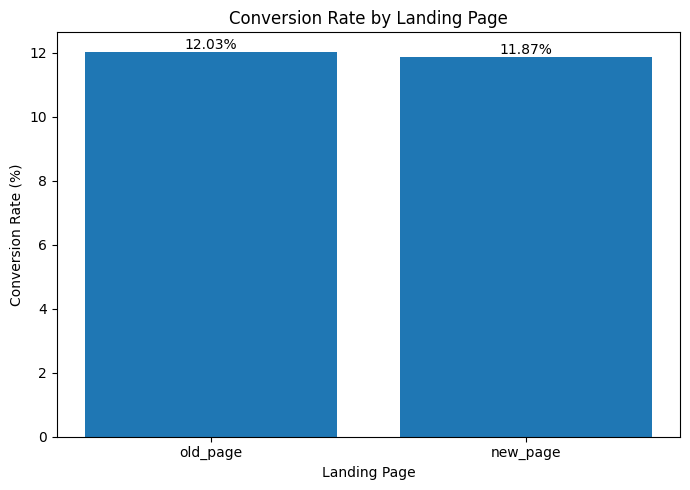

In [3]:
plt.figure(figsize=(7, 5))

plt.bar(
    conversion_summary["landing_page"],
    conversion_summary["conversion_rate_percent"]
)

plt.xlabel("Landing Page")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Landing Page")

for index, value in enumerate(conversion_summary["conversion_rate_percent"]):
    plt.text(
        index,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cr_bar_chart.png", dpi=300)
plt.show()

## Conversion Rate Bar Chart with 95% Confidence Interval

This chart compares conversion rates with 95% confidence intervals.

The confidence interval provides a visual indication of uncertainty around each conversion rate estimate.

If the intervals strongly overlap, it suggests that the difference between the two conversion rates may not be statistically strong.

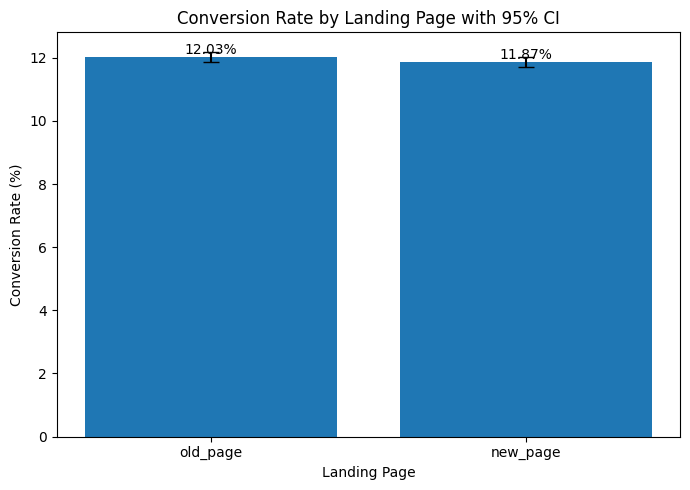

In [4]:
plot_data = conversion_summary.copy()

plot_data["standard_error"] = np.sqrt(
    plot_data["conversion_rate"] *
    (1 - plot_data["conversion_rate"]) /
    plot_data["users"]
)

plot_data["ci_95"] = 1.96 * plot_data["standard_error"]
plot_data["ci_95_percent"] = plot_data["ci_95"] * 100

plt.figure(figsize=(7, 5))

plt.bar(
    plot_data["landing_page"],
    plot_data["conversion_rate_percent"],
    yerr=plot_data["ci_95_percent"],
    capsize=6
)

plt.xlabel("Landing Page")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Landing Page with 95% CI")

for index, value in enumerate(plot_data["conversion_rate_percent"]):
    plt.text(
        index,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cr_bar_ci.png", dpi=300)
plt.show()

## Bootstrap Uplift Distribution

This chart shows the distribution of relative uplift values generated from bootstrap resampling.

The vertical lines represent:

- lower bound of the 95% bootstrap confidence interval
- upper bound of the 95% bootstrap confidence interval
- zero uplift
- mean bootstrap uplift

If the confidence interval contains 0, the observed uplift is not statistically robust.

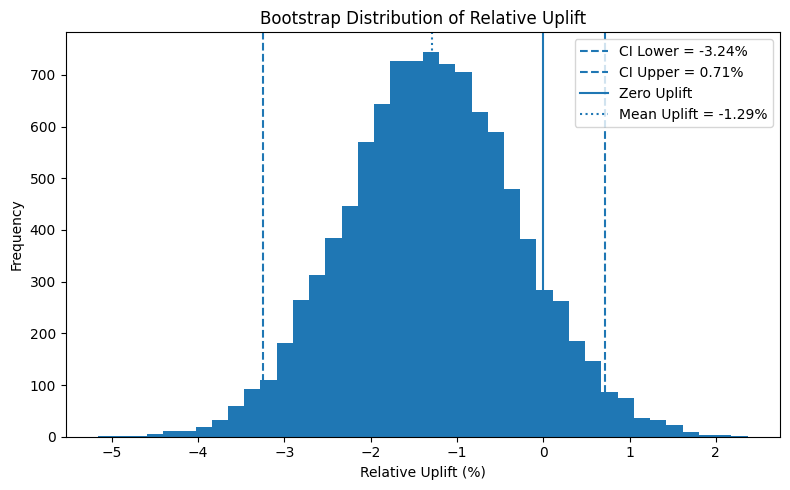

In [5]:
ci_lower = bootstrap_summary.loc[0, "ci_lower"]
ci_upper = bootstrap_summary.loc[0, "ci_upper"]
mean_bootstrap_uplift = bootstrap_summary.loc[0, "mean_bootstrap_uplift"]

plt.figure(figsize=(8, 5))

plt.hist(
    bootstrap_results["bootstrap_uplift"],
    bins=40
)

plt.axvline(
    ci_lower,
    linestyle="--",
    label=f"CI Lower = {ci_lower:.2f}%"
)

plt.axvline(
    ci_upper,
    linestyle="--",
    label=f"CI Upper = {ci_upper:.2f}%"
)

plt.axvline(
    0,
    linestyle="-",
    label="Zero Uplift"
)

plt.axvline(
    mean_bootstrap_uplift,
    linestyle=":",
    label=f"Mean Uplift = {mean_bootstrap_uplift:.2f}%"
)

plt.xlabel("Relative Uplift (%)")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Relative Uplift")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "bootstrap_uplift_distribution.png", dpi=300)
plt.show()

## Country Conversion Rate Bar Chart

This chart compares old_page and new_page conversion rates within each country.

It helps identify whether the new page performs consistently across different markets.

The country-level analysis shows that the UK has a small positive uplift, while the US and CA show negative uplift.

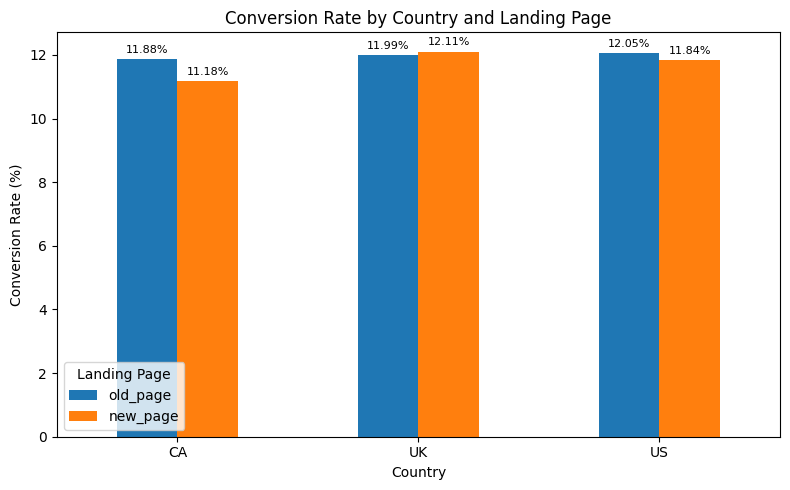

In [6]:
country_cr_plot = country_summary.pivot(
    index="country",
    columns="landing_page",
    values="conversion_rate_percent"
)

country_cr_plot = country_cr_plot[["old_page", "new_page"]]

ax = country_cr_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Country")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Country and Landing Page")
plt.xticks(rotation=0)
plt.legend(title="Landing Page")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "country_cr_bar.png", dpi=300)
plt.show()

## Country Relative Uplift Bar Chart

This chart shows the relative uplift of the new page compared with the old page for each country.

Values above 0 indicate that the new page performs better than the old page.  
Values below 0 indicate that the new page performs worse than the old page.

This chart highlights that CA has the largest negative relative uplift.

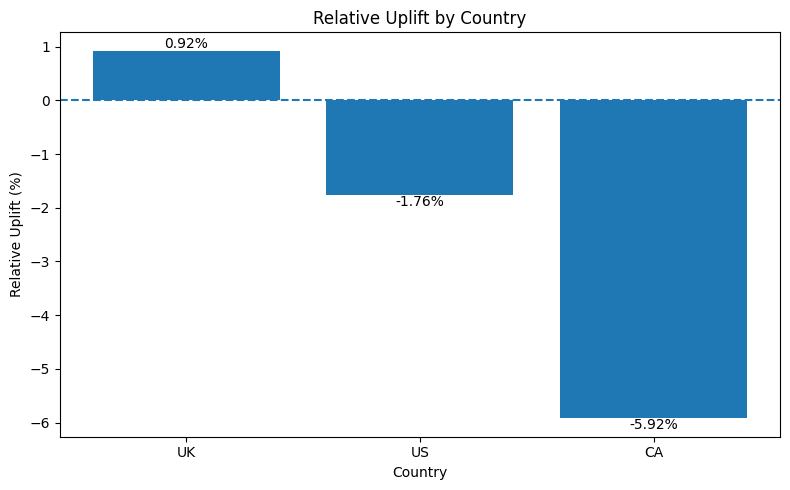

In [7]:
country_uplift_sorted = country_uplift.sort_values(
    by="relative_uplift_percent",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    country_uplift_sorted["country"],
    country_uplift_sorted["relative_uplift_percent"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Country")
plt.ylabel("Relative Uplift (%)")
plt.title("Relative Uplift by Country")

for index, value in enumerate(country_uplift_sorted["relative_uplift_percent"]):
    plt.text(
        index,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "country_uplift_bar.png", dpi=300)
plt.show()

## Country Bootstrap Confidence Interval Plot

This chart shows the mean bootstrap uplift and 95% confidence interval for each country.

The horizontal zero line represents no uplift.

If a country's confidence interval contains 0, the uplift is not statistically robust.

This plot helps communicate uncertainty and downside risk across markets.

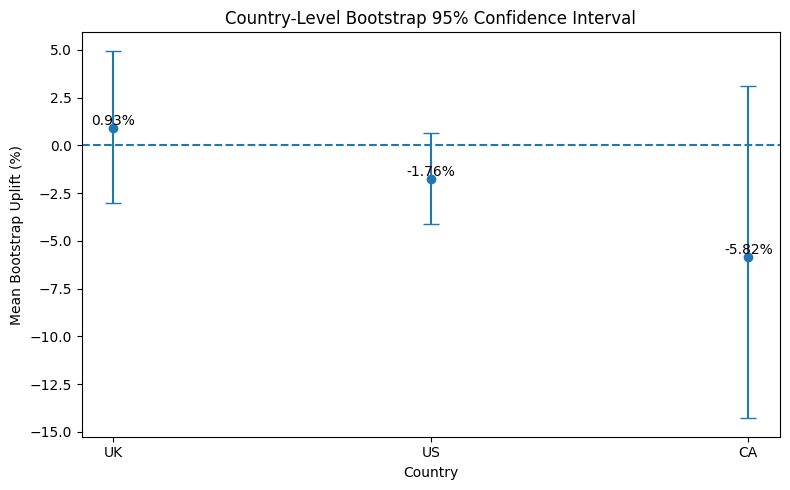

In [8]:
plot_country_ci = country_bootstrap_summary.copy()

plot_country_ci = plot_country_ci.sort_values(
    by="mean_bootstrap_uplift",
    ascending=False
).reset_index(drop=True)

x_positions = np.arange(len(plot_country_ci))

lower_error = (
    plot_country_ci["mean_bootstrap_uplift"]
    - plot_country_ci["ci_lower"]
)

upper_error = (
    plot_country_ci["ci_upper"]
    - plot_country_ci["mean_bootstrap_uplift"]
)

error_values = [lower_error, upper_error]

plt.figure(figsize=(8, 5))

plt.errorbar(
    x_positions,
    plot_country_ci["mean_bootstrap_uplift"],
    yerr=error_values,
    fmt="o",
    capsize=6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xticks(
    x_positions,
    plot_country_ci["country"]
)

plt.xlabel("Country")
plt.ylabel("Mean Bootstrap Uplift (%)")
plt.title("Country-Level Bootstrap 95% Confidence Interval")

for index, row in plot_country_ci.iterrows():
    plt.text(
        index,
        row["mean_bootstrap_uplift"],
        f"{row['mean_bootstrap_uplift']:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "country_bootstrap_ci.png", dpi=300)
plt.show()

## Lift Waterfall Chart

This chart shows the business impact of moving from the old page to the new page.

It visualizes:

- old page conversion rate
- absolute change
- new page conversion rate

This is useful for business communication because it clearly shows the direction and size of the conversion rate change.

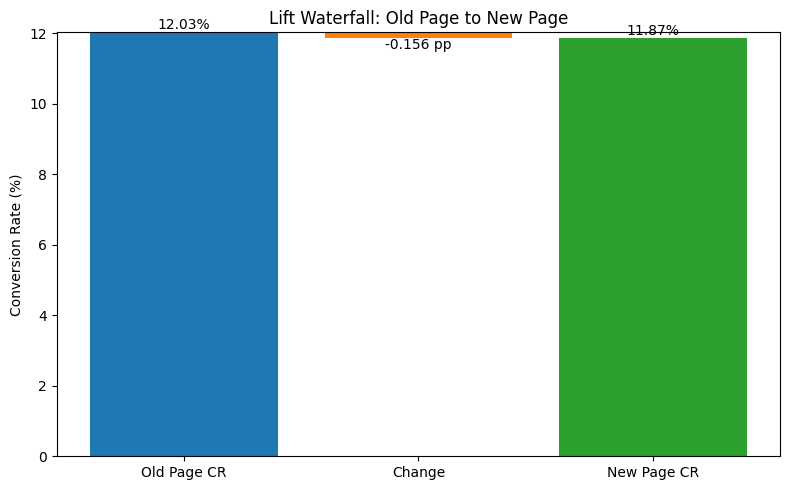

In [9]:
old_cr_percent = lift_summary.loc[0, "old_cr_percent"]
new_cr_percent = lift_summary.loc[0, "new_cr_percent"]
absolute_lift_pp = lift_summary.loc[0, "absolute_lift_pp"]

labels = ["Old Page CR", "Change", "New Page CR"]

plt.figure(figsize=(8, 5))

plt.bar(
    0,
    old_cr_percent
)

plt.bar(
    1,
    absolute_lift_pp,
    bottom=old_cr_percent
)

plt.bar(
    2,
    new_cr_percent
)

plt.xticks(
    [0, 1, 2],
    labels
)

plt.ylabel("Conversion Rate (%)")
plt.title("Lift Waterfall: Old Page to New Page")

plt.text(
    0,
    old_cr_percent,
    f"{old_cr_percent:.2f}%",
    ha="center",
    va="bottom"
)

plt.text(
    1,
    old_cr_percent + absolute_lift_pp,
    f"{absolute_lift_pp:.3f} pp",
    ha="center",
    va="bottom" if absolute_lift_pp >= 0 else "top"
)

plt.text(
    2,
    new_cr_percent,
    f"{new_cr_percent:.2f}%",
    ha="center",
    va="bottom"
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "lift_waterfall.png", dpi=300)
plt.show()

## Check Saved Figures

After generating all charts, we check whether each figure has been successfully saved to the `figures/` directory.

In [10]:
figure_files = [
    "cr_bar_chart.png",
    "cr_bar_ci.png",
    "bootstrap_uplift_distribution.png",
    "country_cr_bar.png",
    "country_uplift_bar.png",
    "country_bootstrap_ci.png",
    "lift_waterfall.png"
]

for file_name in figure_files:
    file_path = FIGURES_DIR / file_name
    print(file_name, file_path.exists())

cr_bar_chart.png True
cr_bar_ci.png True
bootstrap_uplift_distribution.png True
country_cr_bar.png True
country_uplift_bar.png True
country_bootstrap_ci.png True
lift_waterfall.png True


## Summary

This notebook generated visualizations for the A/B testing analysis.

The visualizations include:

1. Conversion rate comparison between old_page and new_page.
2. Conversion rate comparison with 95% confidence intervals.
3. Bootstrap distribution of relative uplift.
4. Country-level conversion rate comparison.
5. Country-level relative uplift.
6. Country-level bootstrap confidence intervals.
7. Lift waterfall chart.

These figures are saved in the `figures/` directory and will be used in the final report, README, and presentation.